# Encoder Workbench

Train, evaluate, and compare per-modality encoders (WiFi / IMU / Odometry / Vision).

**What this notebook does:**
1. Load the multi-modal dataset via `FusionDataModule`
2. Inspect sample shapes, distributions, and temporal structure
3. *(later)* Train & evaluate encoders with linear probing, alignment/uniformity, etc.

In [1]:
import sys, os
from pathlib import Path

# Ensure we're at the repo root regardless of where the kernel started
repo_root = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd()
# If we're inside notebooks/, go up one level
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
# If data dir isn't here, try the known absolute path
if not (repo_root / "data" / "async_collection").exists():
    repo_root = Path(r"c:\Users\Administrateur\navlori-fusion")
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
print(f"Working dir: {os.getcwd()}")
print(f"torch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

Working dir: c:\Users\Administrateur\navlori-fusion
torch 2.6.0+cu124 | CUDA: True


## 1. Load the dataset

In [2]:
from src.pipeline.data import FusionDataModule

dm = FusionDataModule(
    data_dir="data/async_collection",
    train_paths=[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    val_paths=[2, 13, 14],
    test_paths=[15, 16, 17],
    modalities=["imu", "odom", "wifi", "camera"],
    batch_size=64,
    normalize=True,
    wifi_pca=32,  # reduce 117 APs → 32 PCA components (set to None for raw)
)
dm.setup()
print(dm.summary())

Fusion DataModule Summary
  Train: 8524 samples
  Val: 2318 samples
  Test: 2077 samples
  Modalities: ['imu', 'odom', 'wifi', 'camera']
  Feature dims: {'imu': 9, 'odom': 7, 'wifi': 32, 'camera': (3, 224, 224)}
  Windows: {'imu': 32, 'odom': 16, 'wifi': 1, 'camera': 1}
  WiFi PCA: 117 → 32 dims (71.3% variance)
  imu mean range: [-24.669, 0.068]
  imu std range:  [0.003, 91.656]
  odom mean range: [-60.121, 2.440]
  odom std range:  [0.171, 147.311]
  wifi mean range: [-0.000, 0.000]
  wifi std range:  [7.266, 46.158]


## 2. Inspect a single sample

Each sample is anchored to a ground-truth timestamp. The dataloader returns:
- **`imu`**: `(window=32, 9)` — last ~1s of accel_xyz, gyro_xyz, roll/pitch/yaw
- **`odom`**: `(window=16, 7)` — last ~1s of odom_xy, theta, velocities, wheel speeds
- **`wifi`**: `(window=1, N)` — most recent WiFi scan (117 raw APs, or fewer if `wifi_pca` is set)
- **`camera`**: `(3, 224, 224)` — most recent RGB frame, resized + ImageNet-normalized
- **`target`**: `(2,)` — ground truth (x, y) in meters
- **`timestamp`**: scalar — simulation time in seconds

In [3]:
sample = dm.train_ds[100]

print("Keys:", list(sample.keys()))
print()
for key in ["imu", "odom", "wifi", "camera"]:
    t = sample[key]
    print(f"{key:8s}  shape={str(list(t.shape)):16s}  dtype={t.dtype}  range=[{t.min():.3f}, {t.max():.3f}]")
print(f"\ntarget  (x, y) = ({sample['target'][0]:.2f}, {sample['target'][1]:.2f}) m")
print(f"timestamp = {sample['timestamp']:.3f} s")
print(f"path_id = {sample['path_id']}")

Keys: ['target', 'timestamp', 'path_id', 'imu', 'odom', 'wifi', 'camera']

imu       shape=[32, 9]           dtype=torch.float32  range=[-0.175, 0.616]
odom      shape=[16, 7]           dtype=torch.float32  range=[0.003, 0.417]
wifi      shape=[1, 32]           dtype=torch.float32  range=[-2.101, 2.172]
camera    shape=[3, 224, 224]     dtype=torch.float32  range=[-1.810, 2.396]

target  (x, y) = (-4.15, -16.32) m
timestamp = 63.136 s
path_id = 1


## 3. Inspect a batch (from DataLoader)

In [4]:
train_loader = dm.train_dataloader()
batch = next(iter(train_loader))

print(f"Batch size: {batch['target'].shape[0]}")
print()
for key in ["imu", "odom", "wifi", "camera", "target"]:
    print(f"{key:8s}  {list(batch[key].shape)}")

Batch size: 64

imu       [64, 32, 9]
odom      [64, 16, 7]
wifi      [64, 1, 32]
camera    [64, 3, 224, 224]
target    [64, 2]


## 4. Visualize modality windows

Plot what each encoder "sees" for a single sample: IMU time series, odometry trajectory, WiFi fingerprint, and camera frame.

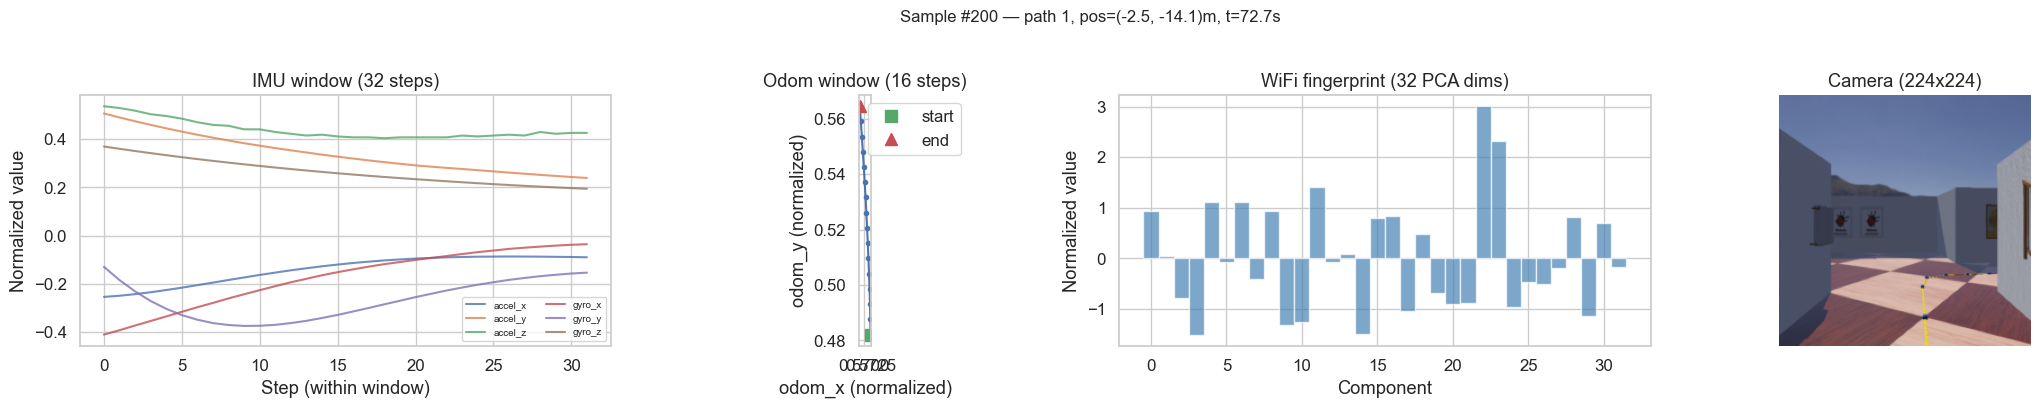

In [5]:
from src.pipeline.data.dataset import IMU_COLS, ODOM_COLS

sample = dm.train_ds[200]  # pick a mid-path sample

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

# --- IMU window (32 steps, 9 features) ---
ax = axes[0]
imu = sample["imu"].numpy()
for i, col in enumerate(IMU_COLS[:6]):  # accel + gyro only
    ax.plot(imu[:, i], label=col, alpha=0.8)
ax.set_title("IMU window (32 steps)")
ax.set_xlabel("Step (within window)")
ax.set_ylabel("Normalized value")
ax.legend(fontsize=7, ncol=2)

# --- Odometry window (16 steps) ---
ax = axes[1]
odom = sample["odom"].numpy()
ax.plot(odom[:, 0], odom[:, 1], "o-", markersize=3)
ax.plot(odom[0, 0], odom[0, 1], "gs", markersize=8, label="start")
ax.plot(odom[-1, 0], odom[-1, 1], "r^", markersize=8, label="end")
ax.set_title("Odom window (16 steps)")
ax.set_xlabel("odom_x (normalized)")
ax.set_ylabel("odom_y (normalized)")
ax.legend()
ax.set_aspect("equal")

# --- WiFi fingerprint ---
ax = axes[2]
wifi = sample["wifi"].numpy().flatten()
ax.bar(range(len(wifi)), wifi, width=1.0, color="steelblue", alpha=0.7)
n_label = f"{len(wifi)} PCA dims" if dm.wifi_pca else f"{len(wifi)} APs"
ax.set_title(f"WiFi fingerprint ({n_label})")
ax.set_xlabel("Component" if dm.wifi_pca else "AP index")
ax.set_ylabel("Normalized value")

# --- Camera frame ---
ax = axes[3]
cam = sample["camera"].numpy()
# Undo ImageNet normalization for display
mean = np.array([0.485, 0.456, 0.406])[:, None, None]
std = np.array([0.229, 0.224, 0.225])[:, None, None]
cam_display = np.clip(cam * std + mean, 0, 1).transpose(1, 2, 0)
ax.imshow(cam_display)
ax.set_title("Camera (224x224)")
ax.axis("off")

fig.suptitle(
    f"Sample #{200} — path {sample['path_id']}, "
    f"pos=({sample['target'][0]:.1f}, {sample['target'][1]:.1f})m, "
    f"t={sample['timestamp']:.1f}s",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

## 5. Target distribution (ground truth positions)

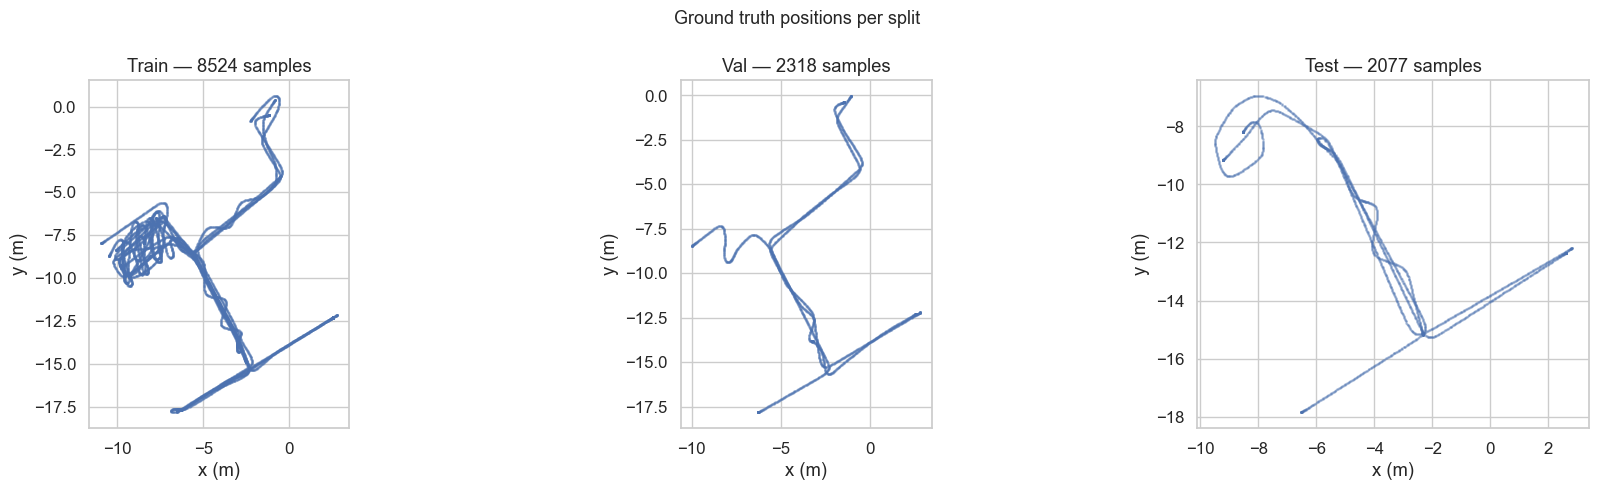

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, ds) in zip(axes, [("Train", dm.train_ds), ("Val", dm.val_ds), ("Test", dm.test_ds)]):
    targets = np.array([ds[i]["target"].numpy() for i in range(len(ds))])
    ax.scatter(targets[:, 0], targets[:, 1], s=1, alpha=0.3)
    ax.set_title(f"{name} — {len(ds)} samples")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal")

plt.suptitle("Ground truth positions per split", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Normalization stats

The training set stats are used for all splits (no data leakage).

In [7]:
import pandas as pd

for mod in ["imu", "odom", "wifi"]:
    stats = dm.train_ds.stats[mod]
    if mod == "imu":
        cols = IMU_COLS
    elif mod == "odom":
        cols = ODOM_COLS
    else:
        n = len(stats["mean"])
        cols = [f"PC_{i}" for i in range(n)] if dm.wifi_pca else [f"AP_{i}" for i in range(n)]

    df = pd.DataFrame({"feature": cols, "mean": stats["mean"], "std": stats["std"]})
    print(f"\n{'='*50}")
    print(f"  {mod.upper()} normalization stats ({len(cols)} features)")
    print(f"{'='*50}")
    print(df.to_string(index=False, float_format="{:.4f}".format))


  IMU normalization stats (9 features)
  feature     mean     std
  accel_x   0.0684  0.1123
  accel_y  -0.0207  0.1729
  accel_z  -0.0014  0.0027
   gyro_x  -0.0002  0.0093
   gyro_y   0.0025  0.0142
   gyro_z  -0.0262  0.3835
 roll_deg  -0.0789  0.3788
pitch_deg  -0.3799  0.2132
  yaw_deg -24.6687 91.6559

  ODOM normalization stats (7 features)
         feature     mean      std
          odom_x   2.4400   4.9637
          odom_y  -1.1451   4.0637
  odom_theta_deg -60.1208 147.3107
 odom_linear_vel   0.6280   0.1714
odom_angular_vel  -0.0542   0.7982
  wheel_left_vel   0.6390   0.2315
 wheel_right_vel   0.6171   0.2393

  WIFI normalization stats (32 features)
feature    mean     std
   PC_0 -0.0000 46.1576
   PC_1 -0.0000 34.0541
   PC_2 -0.0000 13.1429
   PC_3 -0.0000 12.8016
   PC_4  0.0000 11.1830
   PC_5  0.0000 10.4625
   PC_6 -0.0000 10.2371
   PC_7  0.0000  9.8186
   PC_8 -0.0000  9.5790
   PC_9 -0.0000  9.2953
  PC_10 -0.0000  9.0813
  PC_11  0.0000  8.8775
  PC_12  0.0000

## 7. Feature correlation heatmaps

Check inter-feature correlations within each modality (helps decide encoder architecture).

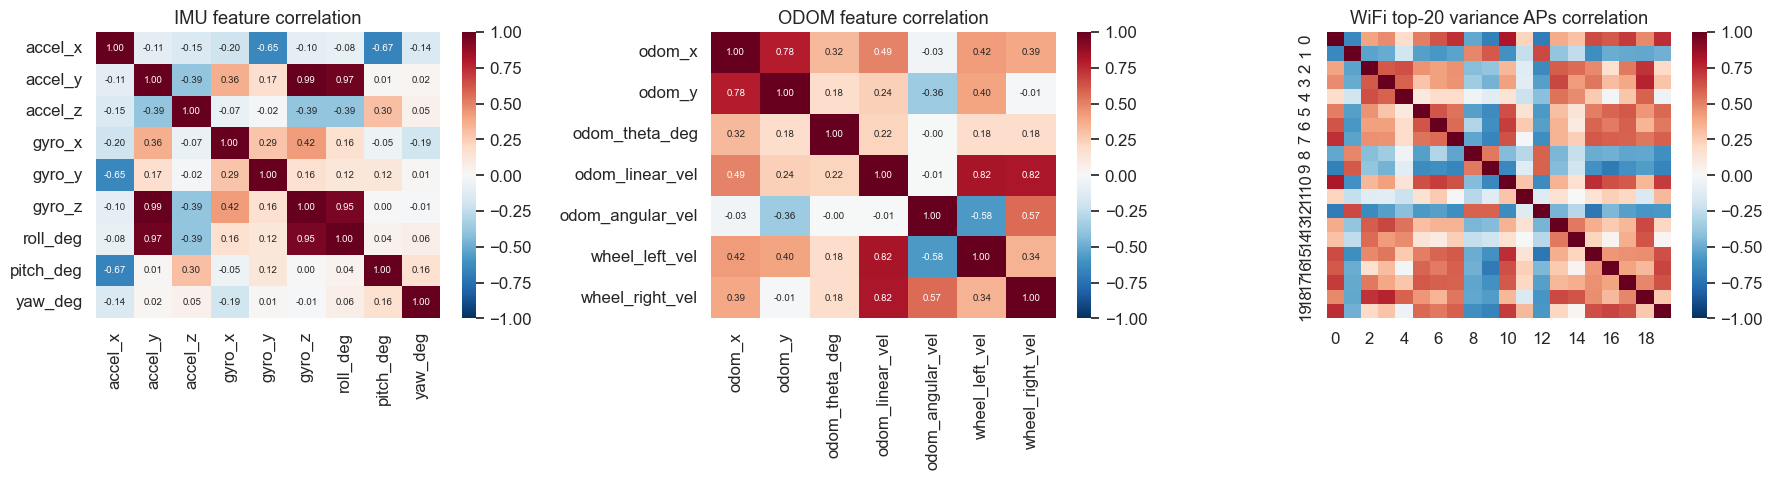

In [8]:
# Gather raw (unnormalized) data for correlation analysis
dm_raw = FusionDataModule(
    data_dir="data/async_collection",
    train_paths=[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    val_paths=[2, 13, 14],
    test_paths=[15, 16, 17],
    modalities=["imu", "odom", "wifi"],  # no camera for correlation
    normalize=False,
)
dm_raw.setup()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (mod, cols) in zip(axes, [("imu", IMU_COLS), ("odom", ODOM_COLS)]):
    # Stack last-step values from N samples
    N = min(500, len(dm_raw.train_ds))
    vals = np.array([dm_raw.train_ds[i][mod][-1].numpy() for i in range(N)])
    corr = np.corrcoef(vals.T)
    sns.heatmap(corr, ax=ax, xticklabels=cols, yticklabels=cols,
                cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
                annot_kws={"fontsize": 7})
    ax.set_title(f"{mod.upper()} feature correlation")

# WiFi: too many features for heatmap — show top-20 variance APs
ax = axes[2]
N = min(500, len(dm_raw.train_ds))
wifi_vals = np.array([dm_raw.train_ds[i]["wifi"].numpy().flatten() for i in range(N)])
variances = wifi_vals.var(axis=0)
top20 = np.argsort(variances)[-20:]
corr_wifi = np.corrcoef(wifi_vals[:, top20].T)
sns.heatmap(corr_wifi, ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, center=0)
ax.set_title(f"WiFi top-20 variance APs correlation")

plt.tight_layout()
plt.show()

## 8. Quick sanity check — KNN baseline

Before building any encoder, check: can a simple K-nearest-neighbors regressor predict (x,y) from raw features? This sets the floor for encoder performance.

> **No camera here** — KNN on raw pixels (150K dims) is meaningless and slow. Vision needs a learned encoder (CNN/ViT) before distance-based methods work.

In [9]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

results = {}

for mod in ["imu", "odom", "wifi"]:
    # Flatten each window into a 1D feature vector
    N_train = len(dm_raw.train_ds)
    N_val = len(dm_raw.val_ds)

    X_train = np.array([dm_raw.train_ds[i][mod].numpy().flatten() for i in range(N_train)])
    y_train = np.array([dm_raw.train_ds[i]["target"].numpy() for i in range(N_train)])

    X_val = np.array([dm_raw.val_ds[i][mod].numpy().flatten() for i in range(N_val)])
    y_val = np.array([dm_raw.val_ds[i]["target"].numpy() for i in range(N_val)])

    knn = KNeighborsRegressor(n_neighbors=5, weights="distance")
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    euclid = np.sqrt(((y_val - y_pred) ** 2).sum(axis=1)).mean()
    results[mod] = {"MAE": mae, "Mean Euclidean (m)": euclid}
    print(f"{mod:6s}  MAE={mae:.3f}m   Mean Euclidean={euclid:.3f}m")

print("\n--- KNN baseline (k=5, raw features, no encoder) ---")
print("This is the floor. Encoders should beat this.")

imu     MAE=3.216m   Mean Euclidean=4.932m
odom    MAE=3.017m   Mean Euclidean=4.640m
wifi    MAE=0.421m   Mean Euclidean=0.633m

--- KNN baseline (k=5, raw features, no encoder) ---
This is the floor. Encoders should beat this.


## 9. Evaluation harness — dummy encoder baseline

Run all 6 evaluation metrics on a **random linear encoder** (untrained).
This establishes the floor: any real encoder must beat these numbers.

In [10]:
import torch.nn as nn
from src.pipeline.evaluation import (
    extract_embeddings, evaluate_encoder, print_report,
)
from src.pipeline.evaluation.encoder_eval import extract_embeddings

# --- Dummy encoder: flatten window → random linear projection → embed_dim ---
class DummyEncoder(nn.Module):
    """Random linear projection — the baseline any real encoder should beat."""
    def __init__(self, input_dim, embed_dim=64):
        super().__init__()
        self.flatten = nn.Flatten()
        self.proj = nn.Linear(input_dim, embed_dim)
    def forward(self, x):
        return self.proj(self.flatten(x))

# We need a DataModule without camera (camera is too slow for dummy baseline)
dm_eval = FusionDataModule(
    data_dir="data/async_collection",
    train_paths=[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    val_paths=[2, 13, 14],
    test_paths=[15, 16, 17],
    modalities=["imu", "odom", "wifi"],
    batch_size=512,
    num_workers=0,  # 0 on Windows/Jupyter — cache is fast enough
    normalize=True,
    wifi_pca=32,
)
dm_eval.setup()
train_loader = dm_eval.train_dataloader()
val_loader = dm_eval.val_dataloader()

In [11]:
# Run full evaluation on each modality with dummy encoder
from src.pipeline.data.dataset import IMU_COLS, ODOM_COLS, DEFAULT_WINDOWS

modality_input_dims = {
    "imu": DEFAULT_WINDOWS["imu"] * len(IMU_COLS),       # 32 * 9 = 288
    "odom": DEFAULT_WINDOWS["odom"] * len(ODOM_COLS),     # 16 * 7 = 112
    "wifi": DEFAULT_WINDOWS["wifi"] * 32,                 # 1 * 32 (PCA)
}

all_results = {}
for mod, in_dim in modality_input_dims.items():
    print(f"\n>>> Evaluating dummy encoder for: {mod} (input_dim={in_dim})")
    encoder = DummyEncoder(input_dim=in_dim, embed_dim=64)

    results = evaluate_encoder(
        encoder=encoder,
        train_loader=train_loader,
        val_loader=val_loader,
        modality=mod,
    )
    print_report(results, modality=mod)
    all_results[mod] = results


>>> Evaluating dummy encoder for: imu (input_dim=288)

  Encoder Evaluation Report — imu
  Linear Probe:     MAE=6.461m  RMSE=8.077m  Euclid=10.488m
  KNN Probe (k=5):  MAE=2.543m  Euclid=3.911m
  Alignment:        1.6715  (lower=better)
  Uniformity:       -1.8790  (lower=better)
  Effective Dim:    PR=7.2/64  95%var=11 dims
  Temporal Smooth:  corr=0.047  mean_dz=0.8223


>>> Evaluating dummy encoder for: odom (input_dim=112)

  Encoder Evaluation Report — odom
  Linear Probe:     MAE=6.408m  RMSE=8.016m  Euclid=10.381m
  KNN Probe (k=5):  MAE=3.226m  Euclid=5.264m
  Alignment:        1.2202  (lower=better)
  Uniformity:       -1.8604  (lower=better)
  Effective Dim:    PR=3.2/64  95%var=4 dims
  Temporal Smooth:  corr=0.530  mean_dz=0.2307


>>> Evaluating dummy encoder for: wifi (input_dim=32)

  Encoder Evaluation Report — wifi
  Linear Probe:     MAE=6.192m  RMSE=7.779m  Euclid=10.135m
  KNN Probe (k=5):  MAE=1.504m  Euclid=2.292m
  Alignment:        1.3308  (lower=better)
  Uni

In [12]:
# Summary comparison table
print(f"\n{'Modality':>10} | {'LP MAE':>8} | {'LP Euclid':>10} | {'KNN MAE':>8} | {'Align':>8} | {'Uniform':>9} | {'Eff.Dim':>8} | {'Temporal':>8}")
print("-" * 95)
for mod, res in all_results.items():
    lp = res["linear_probe"]
    kp = res["knn_probe"]
    au = res["alignment_uniformity"]
    ed = res["effective_dimensionality"]
    ts = res["temporal_smoothness"]
    print(f"{mod:>10} | {lp['mae']:>7.3f}m | {lp['mean_euclidean']:>9.3f}m | {kp['mae']:>7.3f}m | {au['alignment']:>8.4f} | {au['uniformity']:>9.4f} | {ed['participation_ratio']:>7.1f}/{ed['embed_dim']} | {ts['correlation']:>8.3f}")

print("\nThese are RANDOM BASELINE numbers. Any trained encoder must beat them.")


  Modality |   LP MAE |  LP Euclid |  KNN MAE |    Align |   Uniform |  Eff.Dim | Temporal
-----------------------------------------------------------------------------------------------
       imu |   6.461m |    10.488m |   2.543m |   1.6715 |   -1.8790 |     7.2/64 |    0.047
      odom |   6.408m |    10.381m |   3.226m |   1.2202 |   -1.8604 |     3.2/64 |    0.530
      wifi |   6.192m |    10.135m |   1.504m |   1.3308 |   -3.3358 |    18.5/64 |    0.100

These are RANDOM BASELINE numbers. Any trained encoder must beat them.


## 10. Train encoders

Train each modality encoder end-to-end (encoder + linear position head), then run the full 6-metric evaluation.

Training config: AdamW (lr=1e-3), Huber loss, OneCycleLR, gradient clipping, early stopping (patience=25).

In [13]:
from src.pipeline.encoders import WiFiNet, IMUCNN, OdomCNN
from src.pipeline.training import EncoderTrainer

# Use the same DataModule as Section 9 (no camera, wifi_pca=32)
EMBED_DIM = 128
EPOCHS = 100

trained_results = {}
histories = {}

### 10a. WiFi — WiFi-Net

In [14]:
wifi_enc = WiFiNet(n_aps=32, embed_dim=EMBED_DIM, n_anchors=64)
print(f"WiFi WiFiNet: {sum(p.numel() for p in wifi_enc.parameters()):,} params")

trainer = EncoderTrainer(wifi_enc, modality="wifi", dm=dm_eval, patience=25)
histories["wifi"] = trainer.fit(epochs=EPOCHS)
trained_results["wifi"] = trainer.evaluate()

WiFi WiFiNet: 43,777 params
  Epoch   0/100  train_loss=3.3827  val_loss=2.5713  val_mae=8.820m  lr=4.26e-05  *
  Epoch  10/100  train_loss=0.9544  val_loss=1.1172  val_mae=4.151m  lr=3.26e-04  *
  Epoch  20/100  train_loss=0.3382  val_loss=0.3307  val_mae=1.371m  lr=8.04e-04  
  Epoch  30/100  train_loss=0.1318  val_loss=0.1848  val_mae=0.877m  lr=9.99e-04  *
  Epoch  40/100  train_loss=0.0595  val_loss=0.1411  val_mae=0.717m  lr=9.40e-04  *
  Epoch  50/100  train_loss=0.0322  val_loss=0.1374  val_mae=0.702m  lr=7.93e-04  *
  Epoch  60/100  train_loss=0.0221  val_loss=0.1416  val_mae=0.714m  lr=5.88e-04  
  Epoch  70/100  train_loss=0.0188  val_loss=0.1408  val_mae=0.712m  lr=3.66e-04  
  Epoch  80/100  train_loss=0.0171  val_loss=0.1380  val_mae=0.704m  lr=1.70e-04  
  Epoch  89/100  train_loss=0.0163  val_loss=0.1388  val_mae=0.704m  lr=4.89e-05  
  Early stopping at epoch 89 (best=64)
  Done in 14.6s — best val MAE: 0.691m (epoch 64)

  Encoder Evaluation Report — wifi
  Linear Pro

### 10b. IMU — CNN-1D

In [15]:
imu_enc = IMUCNN(in_features=9, embed_dim=EMBED_DIM)
print(f"IMU CNN: {sum(p.numel() for p in imu_enc.parameters()):,} params")

trainer = EncoderTrainer(imu_enc, modality="imu", dm=dm_eval, patience=25)
histories["imu"] = trainer.fit(epochs=EPOCHS)
trained_results["imu"] = trainer.evaluate()

IMU CNN: 49,024 params
  Epoch   0/100  train_loss=3.5108  val_loss=3.1451  val_mae=10.682m  lr=4.26e-05  *
  Epoch  10/100  train_loss=1.1855  val_loss=1.4877  val_mae=4.934m  lr=3.26e-04  *
  Epoch  20/100  train_loss=0.9998  val_loss=1.3422  val_mae=4.447m  lr=8.04e-04  *
  Epoch  30/100  train_loss=0.9200  val_loss=1.2962  val_mae=4.294m  lr=9.99e-04  
  Epoch  40/100  train_loss=0.8892  val_loss=1.2292  val_mae=4.121m  lr=9.40e-04  
  Epoch  50/100  train_loss=0.8227  val_loss=1.1946  val_mae=3.986m  lr=7.93e-04  *
  Epoch  60/100  train_loss=0.7969  val_loss=1.1627  val_mae=3.928m  lr=5.88e-04  
  Epoch  70/100  train_loss=0.7910  val_loss=1.1781  val_mae=3.947m  lr=3.66e-04  
  Epoch  80/100  train_loss=0.7445  val_loss=1.1283  val_mae=3.821m  lr=1.70e-04  
  Epoch  90/100  train_loss=0.7433  val_loss=1.1181  val_mae=3.780m  lr=3.97e-05  
  Epoch  99/100  train_loss=0.7273  val_loss=1.1277  val_mae=3.819m  lr=5.74e-09  
  Done in 20.8s — best val MAE: 3.753m (epoch 81)

  Encode

### 10c. Odometry — CNN-1D

In [16]:
odom_enc = OdomCNN(in_features=7, embed_dim=EMBED_DIM)
print(f"Odom CNN: {sum(p.numel() for p in odom_enc.parameters()):,} params")

trainer = EncoderTrainer(odom_enc, modality="odom", dm=dm_eval, patience=25)
histories["odom"] = trainer.fit(epochs=EPOCHS)
trained_results["odom"] = trainer.evaluate()

Odom CNN: 16,928 params
  Epoch   0/100  train_loss=3.6154  val_loss=3.2970  val_mae=11.105m  lr=4.26e-05  *
  Epoch  10/100  train_loss=1.2474  val_loss=1.6254  val_mae=5.560m  lr=3.26e-04  *
  Epoch  20/100  train_loss=0.6242  val_loss=1.6773  val_mae=5.821m  lr=8.04e-04  
  Epoch  30/100  train_loss=0.5020  val_loss=1.5407  val_mae=5.345m  lr=9.99e-04  
  Epoch  40/100  train_loss=0.4574  val_loss=1.4931  val_mae=5.237m  lr=9.40e-04  
  Epoch  50/100  train_loss=0.4197  val_loss=1.4367  val_mae=5.049m  lr=7.93e-04  
  Epoch  60/100  train_loss=0.4021  val_loss=1.4228  val_mae=5.000m  lr=5.88e-04  
  Epoch  70/100  train_loss=0.3959  val_loss=1.3810  val_mae=4.864m  lr=3.66e-04  
  Epoch  80/100  train_loss=0.3846  val_loss=1.3837  val_mae=4.859m  lr=1.70e-04  
  Epoch  90/100  train_loss=0.3762  val_loss=1.3733  val_mae=4.831m  lr=3.97e-05  
  Epoch  99/100  train_loss=0.3724  val_loss=1.3817  val_mae=4.855m  lr=5.74e-09  
  Done in 15.6s — best val MAE: 4.824m (epoch 82)

  Encoder

### 10d. Comparison — trained vs. random baseline

In [17]:
# Side-by-side: trained encoder vs random baseline
header = f"{'Modality':>10} | {'':^30s} | {'LP MAE':>8} | {'LP Euclid':>10} | {'KNN MAE':>8} | {'Align':>8} | {'Uniform':>9} | {'Eff.Dim':>8} | {'Temporal':>8}"
print(header)
print("-" * len(header))

for mod in ["wifi", "imu", "odom", "camera"]:
    for label, src in [("random", all_results), ("trained", trained_results)]:
        if mod not in src:
            continue
        res = src[mod]
        lp = res["linear_probe"]
        kp = res["knn_probe"]
        au = res["alignment_uniformity"]
        ed = res["effective_dimensionality"]
        ts = res["temporal_smoothness"]
        print(
            f"{mod:>10} | {label:^30s} | {lp['mae']:>7.3f}m | {lp['mean_euclidean']:>9.3f}m | "
            f"{kp['mae']:>7.3f}m | {au['alignment']:>8.4f} | {au['uniformity']:>9.4f} | "
            f"{ed['participation_ratio']:>7.1f}/{ed['embed_dim']} | {ts['correlation']:>8.3f}"
        )
    print()

  Modality |                                |   LP MAE |  LP Euclid |  KNN MAE |    Align |   Uniform |  Eff.Dim | Temporal
---------------------------------------------------------------------------------------------------------------------------
      wifi |             random             |   6.192m |    10.135m |   1.504m |   1.3308 |   -3.3358 |    18.5/64 |    0.100
      wifi |            trained             |   1.743m |     3.010m |   0.394m |   0.0774 |   -1.2913 |     2.8/128 |    0.374

       imu |             random             |   6.461m |    10.488m |   2.543m |   1.6715 |   -1.8790 |     7.2/64 |    0.047
       imu |            trained             |   3.286m |     5.203m |   2.406m |   0.9679 |   -1.8883 |     5.9/128 |    0.383

      odom |             random             |   6.408m |    10.381m |   3.226m |   1.2202 |   -1.8604 |     3.2/64 |    0.530
      odom |            trained             |   3.541m |     5.799m |   2.931m |   0.7232 |   -1.5690 |     4.6/128 | 

### 10e. Training curves

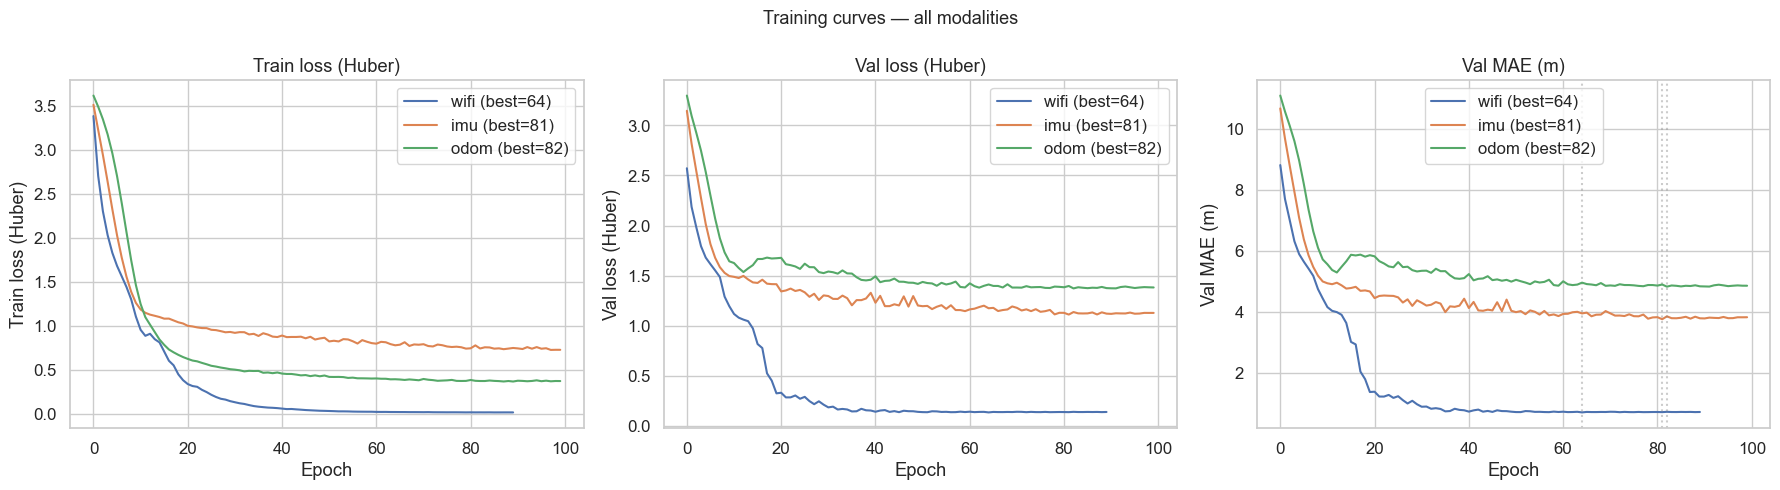


--- Training summary ---
  wifi    best_epoch= 64  best_val_mae=0.691m  time=14.6s
  imu     best_epoch= 81  best_val_mae=3.753m  time=20.8s
  odom    best_epoch= 82  best_val_mae=4.824m  time=15.6s


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, ylabel in zip(
    axes,
    ["train_loss", "val_loss", "val_mae"],
    ["Train loss (Huber)", "Val loss (Huber)", "Val MAE (m)"],
):
    for mod in ["wifi", "imu", "odom", "camera"]:
        if mod not in histories:
            continue
        h = histories[mod]
        values = getattr(h, metric)
        ax.plot(values, label=f"{mod} (best={h.best_epoch})")
        # Mark best epoch on val_mae
        if metric == "val_mae":
            ax.axvline(h.best_epoch, color="gray", linestyle=":", alpha=0.4)

    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()

plt.suptitle("Training curves — all modalities", fontsize=13)
plt.tight_layout()
plt.show()

# Print summary
print("\n--- Training summary ---")
for mod in ["wifi", "imu", "odom", "camera"]:
    if mod not in histories:
        continue
    h = histories[mod]
    print(f"  {mod:6s}  best_epoch={h.best_epoch:3d}  best_val_mae={h.best_val_mae:.3f}m  time={h.elapsed_sec:.1f}s")

### 10f. Vision — ViT-B/16

Vision needs its own DataModule (camera loading is slower than tabular modalities).
The ViT backbone is **frozen** — only the projection head trains.

In [19]:
from src.pipeline.encoders import VisionViT

# Separate DataModule with camera (slower due to image loading)
dm_vision = FusionDataModule(
    data_dir="data/async_collection",
    train_paths=[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    val_paths=[2, 13, 14],
    test_paths=[15, 16, 17],
    modalities=["camera"],
    batch_size=32,  # smaller batch — ViT is memory-heavy on 8GB VRAM
    num_workers=0,  # 0 on Windows/Jupyter — cache is fast enough
    normalize=True,
)
dm_vision.setup()

vision_enc = VisionViT(embed_dim=EMBED_DIM, backbone="vit_b_16", freeze_backbone=True)
n_total = sum(p.numel() for p in vision_enc.parameters())
n_trainable = sum(p.numel() for p in vision_enc.parameters() if p.requires_grad)
print(f"Vision ViT: {n_total:,} total params, {n_trainable:,} trainable (head only)")

trainer = EncoderTrainer(vision_enc, modality="camera", dm=dm_vision, patience=25)
histories["camera"] = trainer.fit(epochs=EPOCHS)
trained_results["camera"] = trainer.evaluate()

Vision ViT: 85,913,856 total params, 115,200 trainable (head only)
  Extracting backbone features (one-time, saved to disk)...
  Loaded backbone features from data\async_collection\.vit_cache\train_features.pt
  Loaded backbone features from data\async_collection\.vit_cache\val_features.pt
  Ready: 8512 train + 2318 val vectors.
  Epoch   0/100  train_loss=1.9401  val_loss=1.5956  val_mae=5.598m  lr=4.26e-05  *
  Epoch  10/100  train_loss=1.1435  val_loss=1.6336  val_mae=5.373m  lr=3.25e-04  
  Epoch  20/100  train_loss=1.1385  val_loss=1.5355  val_mae=5.162m  lr=8.02e-04  
  Epoch  30/100  train_loss=1.1376  val_loss=1.5554  val_mae=5.192m  lr=9.99e-04  
  Epoch  31/100  train_loss=1.1377  val_loss=1.5523  val_mae=5.203m  lr=9.98e-04  
  Early stopping at epoch 31 (best=6)
  Done in 29.3s — best val MAE: 5.007m (epoch 6)

  Encoder Evaluation Report — camera
  Linear Probe:     MAE=3.439m  RMSE=4.339m  Euclid=5.333m
  KNN Probe (k=5):  MAE=3.310m  Euclid=5.057m
  Alignment:        0.2